# Projeto 4 — Álgebra Linear Numérica

---

## Questão 3 — Exponenciais de Matrizes

---
## Item (a) — Autovetores e autovalores de $A(\omega)$

**Enunciado:** Fazer um gráfico dos autovalores de $A(\omega)$ para $\omega$ variando de $0$ a $1$, e também dos autovetores. O que acontece quando $\omega \to 0^+$?

### Solução

**Autovalores.** O polinômio característico de $A(\omega)$ é
$$\det(A(\omega) - \lambda I) = \det\begin{bmatrix} -\lambda & 1 \\ -\omega^2 & -\lambda \end{bmatrix} = \lambda^2 + \omega^2 = 0,$$
donde os autovalores são $\lambda_{\pm} = \pm i\omega$. Para $\omega > 0$ são puramente imaginários; para $\omega = 0$, ambos colapsam em $\lambda = 0$.

**Autovetores.** Para $\lambda_+ = i\omega$ ($\omega > 0$), resolvemos $(A - i\omega I)v = 0$:
$$\begin{bmatrix} -i\omega & 1 \\ -\omega^2 & -i\omega \end{bmatrix} \begin{bmatrix} v_1 \\ v_2 \end{bmatrix} = 0 \implies v_2 = i\omega v_1.$$
Tomando $v_1 = 1$: $v_+ = \begin{bmatrix} 1 \\ i\omega \end{bmatrix}$. Por conjugação, $v_- = \begin{bmatrix} 1 \\ -i\omega \end{bmatrix}$.

**Limite $\omega \to 0^+$.** Os autovalores $\pm i\omega \to 0$ e os autovetores $v_{\pm} \to \begin{bmatrix} 1 \\ 0 \end{bmatrix}$: os dois autovetores distintos colapsam em um único vetor, de modo que $A(0) = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix}$ é uma **matriz defeituosa** (não diagonalizável).

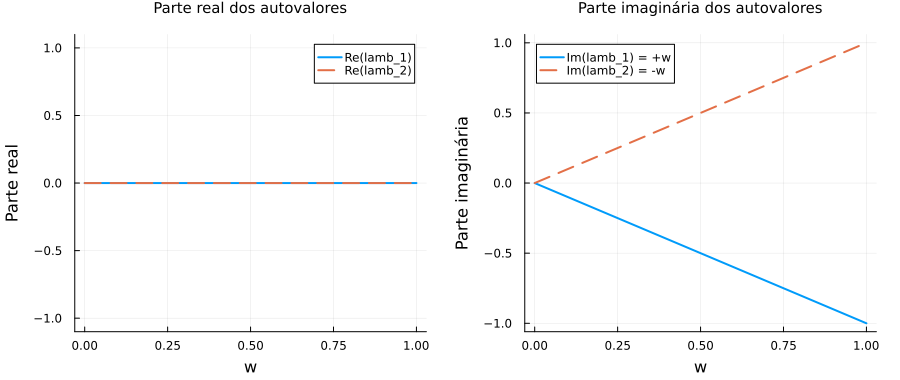

In [411]:
using LinearAlgebra
using Plots

A_omega(w) = [0.0 1.0; -w^2 0.0]

omegas = range(0, 1, length=200)

# Para cada w calculamos os autovalores de A(w). Como já sabemos
# analiticamente que lambda = ±iw, usamos isso só para checar que o
# eigvals do Julia devolve exatamente o que esperamos.
evals_all = [eigvals(A_omega(w)) for w in omegas]

re1 = real.(getindex.(evals_all, 1))
im1 = imag.(getindex.(evals_all, 1))
re2 = real.(getindex.(evals_all, 2))
im2 = imag.(getindex.(evals_all, 2))

p1 = plot(omegas, re1, label="Re(lamb_1)", lw=2,
          xlabel="w", ylabel="Parte real", title="Parte real dos autovalores",
          ylim=(-1.1, 1.1))
plot!(p1, omegas, re2, label="Re(lamb_2)", lw=2, linestyle=:dash)

p2 = plot(omegas, im1, label="Im(lamb_1) = +w", lw=2,
          xlabel="w", ylabel="Parte imaginária", title="Parte imaginária dos autovalores")
plot!(p2, omegas, im2, label="Im(lamb_2) = -w", lw=2, linestyle=:dash)

plot(p1, p2, layout=(1,2), size=(900, 380), titlefontsize=10, margin=4Plots.mm)

Os dois gráficos acima confirmam a análise: a parte real é identicamente zero para todo $\omega$, e as partes imaginárias são $+\omega$ e $-\omega$, partindo ambas de $0$ e se afastando linearmente.

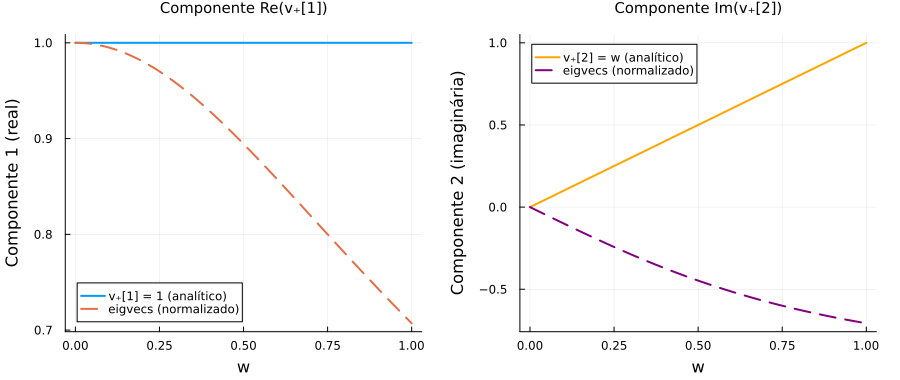

In [412]:
# A solução analítica encontrada acima foi v₊ = [1, iw] (sem normalizar).
# O Julia, por outro lado, devolve autovetores normalizados (norma 1),
# então vamos comparar as duas versões.

# Versão analítica (não normalizada): v₊ = [1, iw]
v1_analitico = ones(length(omegas))            # Re(v₊[1]) = 1 sempre
v2_analitico = imag.(1im .* omegas)            # Im(v₊[2]) = w

# Versão devolvida pelo Julia (eigvecs normaliza as colunas)
evecs_julia = [eigvecs(A_omega(w)) for w in omegas]
v1_julia = real.(getindex.(evecs_julia, 1, 1))
v2_julia = imag.(getindex.(evecs_julia, 2, 1))

p3 = plot(omegas, v1_analitico, label="v₊[1] = 1 (analítico)", lw=2,
          xlabel="w", ylabel="Componente 1 (real)",
          title="Componente Re(v₊[1])")
plot!(p3, omegas, v1_julia, label="eigvecs (normalizado)", lw=2, linestyle=:dash)

p4 = plot(omegas, v2_analitico, label="v₊[2] = w (analítico)", lw=2, color=:orange,
          xlabel="w", ylabel="Componente 2 (imaginária)",
          title="Componente Im(v₊[2])")
plot!(p4, omegas, v2_julia, label="eigvecs (normalizado)", lw=2,
      linestyle=:dash, color=:purple)

plot(p3, p4, layout=(1,2), size=(900, 380), titlefontsize=10, margin=4Plots.mm)

Os gráficos gerados comparam a solução analítica teórica $v_+ = [1, i\omega]^T$ com a solução numérica que o comando `eigvecs` do Julia de fato retorna. Como algoritmos numéricos de alto desempenho exigem que os autovetores possuam norma-2 unitária ($\|v\|_2 = 1$), o Julia aplica uma operação de normalização dividindo o vetor pelo seu comprimento:

$$\|v_+\|_2 = \sqrt{1^2 + \omega^2} = \sqrt{1 + \omega^2}$$

Portanto, a representação interna que o Julia armazena e plota de forma normalizada é:

$$v_{\text{Julia}} = \begin{bmatrix} \frac{1}{\sqrt{1 + \omega^2}} \\ \frac{i\omega}{\sqrt{1 + \omega^2}} \end{bmatrix}$$

Isso explica matematicamente por que as curvas identificadas como "Julia" não são retas:
* No gráfico da esquerda, a linha tracejada descreve a função decrescente $\frac{1}{\sqrt{1 + \omega^2}}$.
* No gráfico da direita, a linha tracejada descreve a curva não linear $\frac{\omega}{\sqrt{1 + \omega^2}}$.

Note que para valores muito pequenos de $\omega$, a curva converge para a aproximação linear ($\omega$), visto que a normalização quase não impacta o vetor quando a magnitude da segunda componente é muito menor que a da primeira ($|v_2| \ll |v_1|$).

**Limite $\omega \to 0^+$.** Em ambas as abordagens (analítica e numérica), quando $\omega \to 0^+$, a componente imaginária desaparece e o vetor unitário resultante converge exatamente para:

$$\lim_{\omega \to 0^+} v_+ = \begin{bmatrix} 1 \\ 0 \end{bmatrix}$$

Como $v_-$ segue o mesmo limite, os dois autovetores independentes colapsam na mesma direção fundamental, confirmando analiticamente e visualmente que $A(0) = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix}$ se torna uma **matriz defeituosa** (não diagonalizável). $\blacksquare$

---
## Item (b) — Condicionamento de $A(\omega)$ e da matriz de autovetores

**Enunciado:** Calcular uma decomposição SVD de $A(\omega)$ e deduzir o número de condicionamento de $A$. Calcular também o condicionamento da matriz de autovetores de $A(\omega)$ em função de $\omega$.

### Condicionamento de $A(\omega)$

**SVD analítica.** Calculamos $A^*A$:
$$A(\omega)^* A(\omega) = \begin{bmatrix} 0 & -\omega^2 \\ 1 & 0 \end{bmatrix}\begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} = \begin{bmatrix} \omega^4 & 0 \\ 0 & 1 \end{bmatrix}.$$
Os valores singulares são $\sigma_1 = 1$ e $\sigma_2 = \omega^2$, portanto:
$$\kappa_2(A(\omega)) = \frac{\sigma_{\max}}{\sigma_{\min}} = \frac{1}{\omega^2}.$$
Para $\omega \to 0^+$, $A(\omega)$ fica **arbitrariamente mal condicionada**.

### Condicionamento da matriz de autovetores

A matriz de autovetores (colunas $v_+$ e $v_-$ normalizados) é, a menos de fator de escala:
$$V(\omega) = \begin{bmatrix} 1 & 1 \\ i\omega & -i\omega \end{bmatrix}.$$
Seu determinante é $-2i\omega$, portanto $V$ é singular para $\omega = 0$. Calculamos $V^*V$:
$$V^*V = \begin{bmatrix} 1 & -i\omega \\ 1 & i\omega \end{bmatrix}\begin{bmatrix} 1 & 1 \\ i\omega & -i\omega \end{bmatrix} = \begin{bmatrix} 1 + \omega^2 & 1 - \omega^2 \\ 1 - \omega^2 & 1 + \omega^2 \end{bmatrix}.$$
Os autovalores de $V^*V$ são $2$ e $2\omega^2$, logo os valores singulares de $V$ são $\sqrt{2}$ e $\omega\sqrt{2}$, e:
$$\kappa_2(V(\omega)) = \frac{\sqrt{2}}{\omega\sqrt{2}} = \frac{1}{\omega}.$$
O condicionamento da matriz de autovetores cresce como $1/\omega$, divergindo para $\omega \to 0^+$: à medida que $A$ se torna defeituosa, o sistema de autovetores fica cada vez mais mal condicionado.

*Observação:* o `eigvecs` do Julia devolve as colunas de $V$ normalizadas (cada uma com norma $\sqrt{1+\omega^2}$ dividindo), mas isso não muda $\kappa_2(V)$, pois ambas as colunas são escaladas pelo mesmo fator — por isso a verificação numérica abaixo dá o mesmo resultado para a versão normalizada e para a versão $[1,\,i\omega]$/$[1,\,-i\omega]$ usada na derivação.

In [413]:
# Verificação numérica da SVD analítica de A(w)
# Calculamos sigma_1, sigma_2 = svdvals(A) e comparamos com os valores
# sigma_1 = 1, sigma_2 = w² que obtivemos resolvendo A*A acima.

using Printf

println("=== Valores singulares de A(w) ===\n")
@printf "%-8s  %-14s  %-14s  %-14s  %-14s\n" "w" "sigma_1 (numérico)" "sigma_2 (numérico)" "sigma_1 (analítico)" "sigma_2=w² (anal.)"
println("-"^65)
for w in [1.0, 0.5, 0.1, 0.01, 0.001]
    sv = svdvals(A_omega(w))
    @printf "%-8.4f  %-14.8f  %-14.8e  %-14.4f  %-14.8e\n" w sv[1] sv[2] 1.0 w^2
end

println()
println("Conferindo também a decomposição completa para w = 0.3:")
w0 = 0.3
F = svd(A_omega(w0))
println("U = ", round.(F.U, digits=4))
println("S = ", round.(F.S, digits=6))
println("V = ", round.(F.V, digits=4))
println("‖U*Diagonal(S)*V' - A‖ = ", norm(F.U * Diagonal(F.S) * F.V' - A_omega(w0)))

=== Valores singulares de A(w) ===

w         sigma_1 (numérico)  sigma_2 (numérico)  sigma_1 (analítico)  sigma_2=w² (anal.)
-----------------------------------------------------------------
1.0000    1.00000000      1.00000000e+00  1.0000          1.00000000e+00
0.5000    1.00000000      2.50000000e-01  1.0000          2.50000000e-01
0.1000    1.00000000      1.00000000e-02  1.0000          1.00000000e-02
0.0100    1.00000000      1.00000000e-04  1.0000          1.00000000e-04
0.0010    1.00000000      1.00000000e-06  1.0000          1.00000000e-06

Conferindo também a decomposição completa para w = 0.3:
U = [1.0 0.0; 0.0 1.0]
S = [1.0, 0.09]
V = [0.0 -1.0; 1.0 -0.0]
‖U*Diagonal(S)*V' - A‖ = 3.1432500083045447e-16


In [414]:
# Condicionamento da matriz de autovetores V(w)
#
# Comparamos duas versões de V:
#  - V_julia: colunas dadas por eigvecs(A), já normalizadas pelo Julia
#  - V_anl:   colunas [1, iw] e [1, -iw], como na derivação analítica
# Como as duas colunas de V têm a mesma escala em ambos os casos,
# o número de condicionamento κ₂ acaba sendo o mesmo nas duas versões.

println("=== Condicionamento da matriz de autovetores V(w) ===\n")
@printf "%-8s  %-16s  %-16s  %-12s\n" "w" "κ(V_julia)" "κ(V_analítico)" "1/w (teórico)"
println("-"^56)
for w in [1.0, 0.5, 0.1, 0.01, 0.001, 0.0001]
    V_julia = eigvecs(A_omega(w))
    V_anl   = [1.0 1.0; 1im*w -1im*w]
    κ_julia = cond(V_julia)
    κ_anl   = cond(V_anl)
    @printf "%-8.4f  %-16.6f  %-16.6f  %-12.6f\n" w κ_julia κ_anl (1/w)
end

=== Condicionamento da matriz de autovetores V(w) ===

w         κ(V_julia)        κ(V_analítico)    1/w (teórico)
--------------------------------------------------------
1.0000    1.000000          1.000000          1.000000    
0.5000    2.000000          2.000000          2.000000    
0.1000    10.000000         10.000000         10.000000   
0.0100    100.000000        100.000000        100.000000  
0.0010    1000.000000       1000.000000       1000.000000 
0.0001    10000.000000      10000.000000      10000.000000


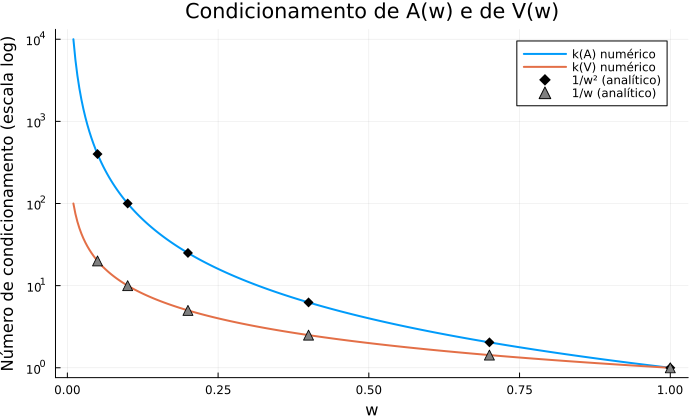

In [415]:
# Gráfico comparativo: k(A) e k(V) em função de w
omegas_pos = range(0.01, 1, length=300)   # evitamos w = 0 (cond explode)

kappa_A = [cond(A_omega(w)) for w in omegas_pos]
kappa_V = [cond(eigvecs(A_omega(w))) for w in omegas_pos]

plot(omegas_pos, kappa_A,
     label="k(A) numérico", lw=2, yscale=:log10,
     xlabel="w", ylabel="Número de condicionamento (escala log)",
     title="Condicionamento de A(w) e de V(w)", legend=:topright,
     size=(700,420))
plot!(omegas_pos, kappa_V, label="k(V) numérico", lw=2)

# Em vez de sobrepor outra linha (que ficaria escondida atrás da curva
# numérica, já que coincidem quase perfeitamente), marcamos alguns
# pontos da fórmula analítica com símbolos para comparação visual.
omegas_ref = [0.05, 0.1, 0.2, 0.4, 0.7, 1.0]
scatter!(omegas_ref, 1 ./ omegas_ref.^2, label="1/w² (analítico)",
         marker=:diamond, ms=5, color=:black)
scatter!(omegas_ref, 1 ./ omegas_ref, label="1/w (analítico)",
         marker=:utriangle, ms=5, color=:gray)

O gráfico em escala log confirma na prática o que calculamos à mão: $\kappa_2(A) = 1/\omega^2$ cresce a uma taxa quadrática, bem mais rápido e íngreme do que $\kappa_2(V) = 1/\omega$. Além disso, as curvas do Julia batem exatamente em cima das marcações teóricas. Mas além de apenas confirmar a álgebra, essa explosão simultânea das curvas quando $\omega \to 0^+$ mostra o efeito real do limite no sistema:

Colapso da base de autovetores ($\kappa(V) \to \infty$): Quando o condicionamento de $V$ vai para o infinito, significa geometricamente que o ângulo entre os autovetores $v_+$ e $v_-$ está sumindo. As colunas de $V$ ficam quase linearmente dependentes. Se tentarmos rodar qualquer operação numérica que exija inverter $V$ (como a diagonalização $A = V \Lambda V^{-1}$), o computador vai sofrer um cancelamento catastrófico e os erros de arredondamento vão explodir.

A prova da matriz defeituosa: Essa divergência do $\kappa(V)$ é a consequência numérica direta do que demonstramos no item (a). No limite zero, $A(\omega)$ perde seus autovetores independentes e colapsa em uma matriz defeituosa, destruindo de a possibilidade de diagonalização.

---
## Item (c) — Bônus: Exponencial de $A(\omega)$

**Enunciado:** Mostrar que $A(\omega)^2 = -\omega^2 I$. Deduzir da série de Taylor que $e^{tA(\omega)} = \cos(\omega t)I + \frac{\sin(\omega t)}{\omega} A(\omega)$. Calcular $e^{tA(\omega)}$ no computador e verificar o limite $\omega \to 0^+$.

### $A(\omega)^2 = -\omega^2 I$

Calculamos diretamente:
$$A(\omega)^2 = \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix}\begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} = \begin{bmatrix} -\omega^2 & 0 \\ 0 & -\omega^2 \end{bmatrix} = -\omega^2 I. \quad \blacksquare$$

### Dedução da fórmula para $e^{tA(\omega)}$

Como $A^2 = -\omega^2 I$, as potências de $A$ seguem o padrão:
$$A^{2k} = (-\omega^2)^k I, \qquad A^{2k+1} = (-\omega^2)^k A.$$

Substituindo na série de Taylor $e^{tA} = \sum_{n=0}^{\infty} \frac{t^n A^n}{n!}$ e separando termos pares e ímpares:
$$e^{tA} = \sum_{k=0}^{\infty} \frac{t^{2k}}{(2k)!} (-\omega^2)^k I + \sum_{k=0}^{\infty} \frac{t^{2k+1}}{(2k+1)!} (-\omega^2)^k A.$$

Reconhecemos as séries de cosseno e seno:
$$\sum_{k=0}^{\infty} \frac{(-1)^k (\omega t)^{2k}}{(2k)!} = \cos(\omega t), \qquad \sum_{k=0}^{\infty} \frac{(-1)^k (\omega t)^{2k+1}}{(2k+1)!} = \sin(\omega t).$$

Assim:
$$e^{tA} = \cos(\omega t)\, I + \frac{1}{\omega}\sum_{k=0}^{\infty} \frac{(-1)^k (\omega t)^{2k+1}}{(2k+1)!} A = \cos(\omega t)\, I + \frac{\sin(\omega t)}{\omega} A(\omega).$$

$$\boxed{e^{tA(\omega)} = \cos(\omega t)\, I + \frac{\sin(\omega t)}{\omega}\, A(\omega).} \quad \blacksquare$$

### Limite $\omega \to 0^+$

Como $\lim_{\omega \to 0} \frac{\sin(\omega t)}{\omega} = t$, temos:
$$\lim_{\omega \to 0^+} e^{tA(\omega)} = I + t\, A(0) = \begin{bmatrix} 1 & t \\ 0 & 1 \end{bmatrix} = e^{tA(0)},$$
que é de fato a exponencial da matriz nilpotente $A(0) = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix}$ (cuja série termina em dois termos, pois $A(0)^2 = 0$).

In [416]:
# Verificação numérica de A(w)² = -w²I
println("=== Verificação: A(w)² = -w²I ===")
for w in [0.1,  0.25, 0.5, 0.75, 1.0]
    A = A_omega(w)
    err = norm(A^2 - (-w^2) * I)
    @printf "w = %.2f:  ||A² + w²I|| = %.2e\n" w err
end

=== Verificação: A(w)² = -w²I ===
w = 0.10:  ||A² + w²I|| = 0.00e+00
w = 0.25:  ||A² + w²I|| = 0.00e+00
w = 0.50:  ||A² + w²I|| = 0.00e+00
w = 0.75:  ||A² + w²I|| = 0.00e+00
w = 1.00:  ||A² + w²I|| = 0.00e+00


In [417]:
using LinearAlgebra: exp   # exp(A) para matrizes

"""
    expm_formula(w, t)

Calcula e^{tA(w)} pela fórmula analítica derivada acima:
    e^{tA} = cos(wt) I + sin(wt)/w * A(w)
"""
function expm_formula(w::Real, t::Real)
    A = A_omega(w)
    return cos(w * t) * I + (sin(w * t) / w) * A
end

# Comparação com exp() numérica para vários w e t
println("=== Erro relativo: fórmula vs. exp() numérica ===\n")
@printf "%-8s  %-8s  %-20s\n" "w" "t" "||E_fórmula - E_num|| / ||E_num||"
println("-"^42)
for w in [1.0, 0.5, 0.1, 0.01], t in [0.5, 1.0, 2.0, 5.0]
    E_formula = expm_formula(w, t)
    E_numeric = exp(t * A_omega(w))
    err_rel = norm(E_formula - E_numeric) / norm(E_numeric)
    @printf "%-8.4f  %-8.2f  %-20.2e\n" w t err_rel
end

=== Erro relativo: fórmula vs. exp() numérica ===

w         t         ||E_fórmula - E_num|| / ||E_num||
------------------------------------------
1.0000    0.50      9.61e-17            
1.0000    1.00      7.85e-17            
1.0000    2.00      1.18e-16            
1.0000    5.00      1.42e-16            
0.5000    0.50      7.65e-17            
0.5000    1.00      1.00e-16            
0.5000    2.00      5.86e-17            
0.5000    5.00      7.41e-17            
0.1000    0.50      5.79e-19            
0.1000    1.00      1.44e-16            
0.1000    2.00      1.37e-16            
0.1000    5.00      2.25e-17            
0.0100    0.50      1.53e-16            
0.0100    1.00      9.07e-17            
0.0100    2.00      4.53e-17            
0.0100    5.00      0.00e+00            


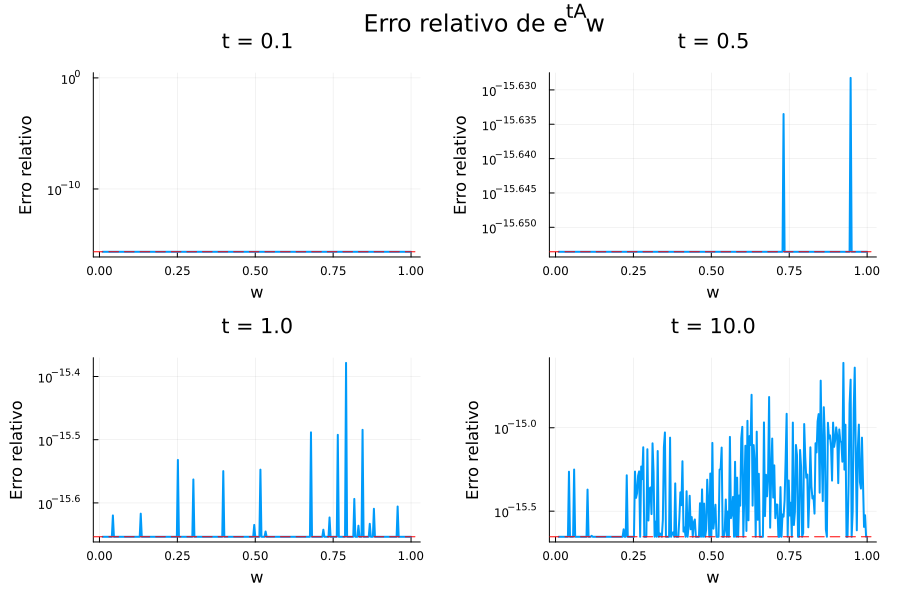

In [418]:
# Gráfico do erro relativo em função de w para vários t
t_s = [0.1, 0.5, 1.0, 10.0]
omegas_graf = range(0.01, 1.0, length=300)
piso = eps(Float64)

graficos = []

for t_fixo in t_s
    erros_rel = [
        norm(expm_formula(w, t_fixo) - exp(t_fixo * A_omega(w))) /
        norm(exp(t_fixo * A_omega(w)))
        for w in omegas_graf
    ]

    # Alguns erros relativos saem como exatamente 0.0 (a fórmula e o exp()
    # coincidem bit a bit nesses pontos). Como log10(0) = -Inf, isso quebra
    # o gráfico em escala log. Para visualizar, colocamos um "piso" em
    # eps(Float64), que é o menor valor que faz sentido mostrar de qualquer
    # forma (representa precisão de máquina).
    erros_plot = max.(erros_rel, piso)

    p = plot(omegas_graf, erros_plot,
         yscale=:log10,
         xlabel="w",
         ylabel="Erro relativo",
         title="t = $t_fixo",
         label="||E_fórmula − E_num||",
         lw=2, legend=false)
         
    hline!(p, [piso], linestyle=:dash, color=:red,
           label="eps ≈ 2.2e-16")
           
    push!(graficos, p)
end

plot(graficos..., 
     layout=(2,2), 
     size=(900, 600), 
     margin=4Plots.mm,
     plot_title="Erro relativo de e^{tA(w)}: fórmula vs. exp() numérica")

O gráfico mostra os erros relativos limitados pela precisão de máquina (em torno de $10^{-16}$) para todo $\omega \in [0.01, 1]$. Vários pontos chegam a ser exatamente $0$ (fórmula e `exp()` coincidem bit a bit); para esses casos usamos um "piso" em `eps(Float64)` apenas para que o ponto apareça na escala logarítmica, já que $\log_{10}(0)$ não está definido. Em todos os casos, a fórmula analítica $e^{tA} = \cos(\omega t)I + \frac{\sin(\omega t)}{\omega}A(\omega)$ é numericamente equivalente ao cálculo direto via `exp()`.

In [419]:
# Verificação do limite w → 0⁺: a fórmula deve tender a e^{tA(0)} = I + tA(0)
t_lim = 1.0
A0    = [0.0 1.0; 0.0 0.0]           # A(0)
E_lim = I + t_lim * A0               # e^{tA(0)} = I + tA(0)  (pois A(0)² = 0)

println("e^{tA(0)} = I + tA(0) =")
display(E_lim)
println()

println("=== Limite w → 0⁺: fórmula vs. e^{tA(0)} ===\n")
@printf "%-12s  %-22s  %-22s\n" "w" "||E_fórmula − E_lim||" "||E_num − E_lim||"
println("-"^60)
for w in [0.1, 0.01, 0.001, 0.0001, 0.00001]
    E_form = expm_formula(w, t_lim)
    E_num  = exp(t_lim * A_omega(w))
    err_form = norm(E_form - E_lim)
    err_num  = norm(E_num  - E_lim)
    @printf "%-12.5f  %-22.6e  %-22.6e\n" w err_form err_num
end

2×2 Matrix{Float64}:
 1.0  1.0
 0.0  1.0

e^{tA(0)} = I + tA(0) =

=== Limite w → 0⁺: fórmula vs. e^{tA(0)} ===

w             ||E_fórmula − E_lim||   ||E_num − E_lim||     
------------------------------------------------------------
0.10000       1.234337e-02            1.234337e-02          
0.01000       1.236016e-04            1.236016e-04          
0.00100       1.236033e-06            1.236033e-06          
0.00010       1.236033e-08            1.236033e-08          
0.00001       1.236033e-10            1.236033e-10          


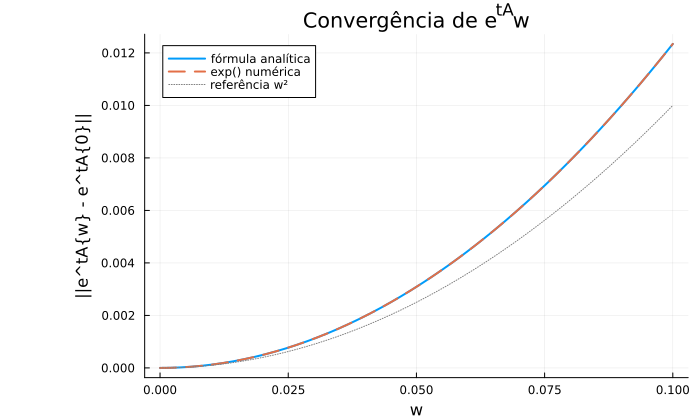

In [420]:
# Gráfico: convergência de e^{tA(w)} para e^{tA(0)} quando w → 0⁺
omegas_lim = range(1e-15, 0.1, length=50)   

erros_lim_form = [norm(expm_formula(w, t_lim) - E_lim) for w in omegas_lim]
erros_lim_num  = [norm(exp(t_lim * A_omega(w))  - E_lim) for w in omegas_lim]

plot(omegas_lim, erros_lim_form,
     xlabel="w",
     #ylabel="||e^{tA(w)} - e^{tA(0)}||",
     ylabel="||e^tA{w} - e^tA{0}||",
     title="Convergência de e^{tA(w)} para e^{tA(0)}  (t = $t_lim)",
     label="fórmula analítica", left_margin=20Plots.mm, lw=2, size=(700,420)),

plot!(omegas_lim, erros_lim_num,
      label="exp() numérica", lw=2, linestyle=:dash)

# Linha de referência w² (a fórmula converge como O(w²))
plot!(omegas_lim, omegas_lim.^2,
      label="referência w²", lw=1, linestyle=:dot, color=:gray)

O gráfico mostra que $\|e^{tA(\omega)} - e^{tA(0)}\| \to 0$ à taxa $O(\omega^2)$ quando $\omega \to 0^+$, tanto para a fórmula analítica quanto para o cálculo numérico direto via `exp()`. 

Para demonstrar analiticamente esse decaimento, partimos da diferença entre a fórmula fechada e o limite $e^{tA(0)} = I + tA(0)$:$$e^{tA(\omega)} - e^{tA(0)} = (\cos(\omega t) - 1)I + \frac{\sin(\omega t)}{\omega} A(\omega) - tA(0)$$Expandimos os termos trigonométricos em série de Taylor em torno de $\omega = 0$, mantendo explícitos os termos de grau superior:

Termo do cosseno: $\cos(\omega t) - 1 = -\frac{t^2}{2}\omega^2 + \frac{t^4}{24}\omega^4 - \frac{t^6}{720}\omega^6 + \dots$

Termo do seno: $\frac{\sin(\omega t)}{\omega} = \frac{\omega t - \frac{t^3}{6}\omega^3 + \frac{t^5}{120}\omega^5 - \dots}{\omega} = t - \frac{t^3}{6}\omega^2 + \frac{t^5}{120}\omega^4 - \dots$


Além disso, separamos a matriz $A(\omega)$ na sua parte constante e na matriz de perturbação multiplicada por $\omega^2$:$$A(\omega) = \begin{bmatrix} 0 & 1 \\ -\omega^2 & 0 \end{bmatrix} = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix} + \omega^2 \begin{bmatrix} 0 & 0 \\ -1 & 0 \end{bmatrix} = A(0) + \omega^2 K$$

Substituindo essas expansões na equação original, obtemos:$$e^{tA(\omega)} - e^{tA(0)} = \left( -\frac{t^2}{2}\omega^2 + \frac{t^4}{24}\omega^4 - \dots \right) I + \left( t - \frac{t^3}{6}\omega^2 + \frac{t^5}{120}\omega^4 - \dots \right) (A(0) + \omega^2 K) - tA(0)$$

Distribuindo o produto no termo do seno:$$e^{tA(\omega)} - e^{tA(0)} = \left( -\frac{t^2}{2}\omega^2 + \frac{t^4}{24}\omega^4 - \dots \right) I + tA(0) - \frac{t^3}{6}\omega^2 A(0) + \frac{t^5}{120}\omega^4 A(0) + t\omega^2 K - \frac{t^3}{6}\omega^4 K + \dots - tA(0)$$Note que os termos lineares $tA(0)$ se cancelam.

 Agora, agrupamos todos os termos remanescentes de acordo com as potências de $\omega$:$$e^{tA(\omega)} - e^{tA(0)} = \omega^2 \left( -\frac{t^2}{2}I - \frac{t^3}{6}A(0) + tK \right) + \omega^4 \left( \frac{t^4}{24}I + \frac{t^5}{120}A(0) - \frac{t^3}{6}K \right) + \dots$$
 
 Como os termos $tA(0)$ sumiram, a menor potência de $\omega$ que sobrevive na diferença é exatamente $\omega^2$. Podemos então compactar as matrizes resultantes (que dependem apenas de $t$) na notação assintótica:$$e^{tA(\omega)} - e^{tA(0)} = O(\omega^2)$$A convergência evidenciada no gráfico, onde a fórmula analítica e o cálculo numérico coincidem confirma numericamente essa dedução teórica.